Rahul Sen

EDA Assignment

In [1]:
import numpy as np
import pandas as pd


In [2]:
df=pd.read_csv("E:\\Data_science\\assignments\\EDA Assignment\\EDA Assignment Assignment.csv")
df.head()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30


Q1. What is the maximum number of matches played by an individual player in a season? Print the player name along with the number of matched played.

In [4]:
Max_matches=max(df['Matches'])
player_max_matches=df[df['Matches']==Max_matches]
print('Players with maximum number of matches are:-')
print(player_max_matches[['Player','Matches']])

Players with maximum number of matches are:-
            Player  Matches
1   Shikhar Dhawan       17
3     Shreyas Iyer       17
19  Marcus Stoinis       17
67   Kagiso Rabada       17


Q2. Top 2 players with maximum Average who have scored atleast 2 half centuries.

In [6]:
Player_2_50s=df[df['50']>=2]
player_max_avg=Player_2_50s.sort_values(by='Avg',ascending=False).head(2)
player_max_avg[['Player','Avg']]

,Player,Avg
36,Wriddhiman Saha,71.33
4,Ishan Kishan,57.33


Q3.  Create 2 new columns based on Player name. First column will have first name and second column will have last name. Eg: for the player Shikhar Dhawan, Shikhar will be the first name and Dhawan will be the last name.

In [8]:
df[['First_name','Last_name']]=df['Player'].str.split(' ',n=1,expand=True)
df.head()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,First_name,Last_name
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23,KL,Rahul
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12,Shikhar,Dhawan
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14,David,Warner
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16,Shreyas,Iyer
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30,Ishan,Kishan


Q4. Create a new column (Cleaned_Highest_score) based on Highest score variable. Remove the Asterik(*) mark and convert the data type into INT.

In [10]:

df['Cleaned_Highest_Score']=(df['Highest Score'].str.replace('*','')).astype(int)
df.drop('Highest Score',axis=1, inplace=True)
df.head()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Avg,Balls faced,Strike rate,100,50,4s,6s,First_name,Last_name,Cleaned_Highest_Score
0,1,KL Rahul,14,14,2,670,55.83,518,129.34,1,5,58,23,KL,Rahul,132
1,2,Shikhar Dhawan,17,17,3,618,44.14,427,144.73,2,4,67,12,Shikhar,Dhawan,106
2,3,David Warner,16,16,2,548,39.14,407,134.64,0,4,52,14,David,Warner,85
3,4,Shreyas Iyer,17,17,2,519,34.60,421,123.27,0,3,40,16,Shreyas,Iyer,88
4,5,Ishan Kishan,14,13,4,516,57.33,354,145.76,0,4,36,30,Ishan,Kishan,99


In [11]:
df['Cleaned_Highest_Score'].dtype

dtype('int32')

Q5. Print the total number of centuries scored in the entire season.

In [13]:
Total_100s=df['100'].sum()
print("Total number of centuries scored:-",Total_100s)

Total number of centuries scored:- 5


Q6. Print all the player names whose strike rate is less than the average strike rate of all players in entire season. Print the player name, his strike rate and average strike rate

In [15]:
Avg_strike=(df['Strike rate'].sum())/(df['Strike rate'].count())
filtered_list=df[df['Strike rate']<=Avg_strike]
print("Average Strike rate is:-",Avg_strike)
print("\nPlayers whose strike rate is less than avg strike rate:-\n",filtered_list[['Player','Strike rate']])

Average Strike rate is:- 107.36473684210526

Players whose strike rate is less than avg strike rate:-
                   Player  Strike rate
51        Ajinkya Rahane       105.60
55         Glenn Maxwell       101.88
58         Vijay Shankar       101.04
61         Josh Philippe       101.29
62       Gurkeerat Singh        88.75
65          Kedar Jadhav        93.93
70      Yashasvi Jaiswal        90.90
71         Shreyas Gopal        94.87
77          Murali Vijay        74.41
79          Chris Jordan        93.54
80         Navdeep Saini       100.00
82     Kamlesh Nagarkoti        70.96
84         Harshal Patel        87.50
85         Jimmy Neesham       105.55
86            Tom Banton        90.00
89     Prabhsimran Singh       100.00
92         Kuldeep Yadav        61.90
94             Moeen Ali        75.00
95        Sandeep Sharma        80.00
96        Shardul Thakur        57.14
98           Rinku Singh       100.00
99           Shivam Mavi        71.42
100  Varun Chakaravarth

Q7. Please check the correlation between the features and create a heat map.

In [17]:
num_col = [fea for fea in df.columns if df[fea].dtypes !='object']
num_col

['Jersey No',
 'Matches',
 'Inns',
 'Not Out',
 'Runs',
 'Avg',
 'Balls faced',
 'Strike rate',
 '100',
 '50',
 '4s',
 '6s',
 'Cleaned_Highest_Score']

In [18]:
numeric_data=df[num_col]

In [19]:
numeric_data.drop('Jersey No',axis=1, inplace=True) #jersey number is of no use.

C:\Users\rahul\AppData\Local\Temp\ipykernel_12244\3272513420.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numeric_data.drop('Jersey No',axis=1, inplace=True) #jersey number is of no use.


In [20]:
correlation=numeric_data.corr()
correlation

,Matches,Inns,Not Out,Runs,Avg,Balls faced,Strike rate,100,50,4s,6s,Cleaned_Highest_Score
Matches,1.000000,0.728358,0.555261,0.565237,0.306128,0.555102,0.371328,0.128405,0.455437,0.522628,0.523367,0.456171
Inns,0.728358,1.000000,0.464356,0.895914,0.585148,0.889753,0.581468,0.224328,0.755027,0.846749,0.810922,0.832002
Not Out,0.555261,0.464356,1.000000,0.308747,0.429888,0.271021,0.415060,0.019726,0.174184,0.204779,0.391472,0.235613
Runs,0.565237,0.895914,0.308747,1.000000,0.687475,0.989948,0.517678,0.382577,0.912264,0.959576,0.861166,0.913250
Avg,0.306128,0.585148,0.429888,0.687475,1.000000,0.664173,0.591306,0.233726,0.638326,0.623643,0.646224,0.774646
Balls faced,0.555102,0.889753,0.271021,0.989948,0.664173,1.000000,0.474226,0.358550,0.900547,0.955994,0.810916,0.904798
Strike rate,0.371328,0.581468,0.415060,0.517678,0.591306,0.474226,1.000000,0.135331,0.406029,0.465132,0.566317,0.608398
100,0.128405,0.224328,0.019726,0.382577,0.233726,0.358550,0.135331,1.000000,0.292812,0.456622,0.186767,0.383540
50,0.455437,0.755027,0.174184,0.912264,0.638326,0.900547,0.406029,0.292812,1.000000,0.892025,0.757501,0.841283
4s,0.522628,0.846749,0.204779,0.959576,0.623643,0.955994,0.465132,0.456622,0.892025,1.000000,0.731094,0.875322


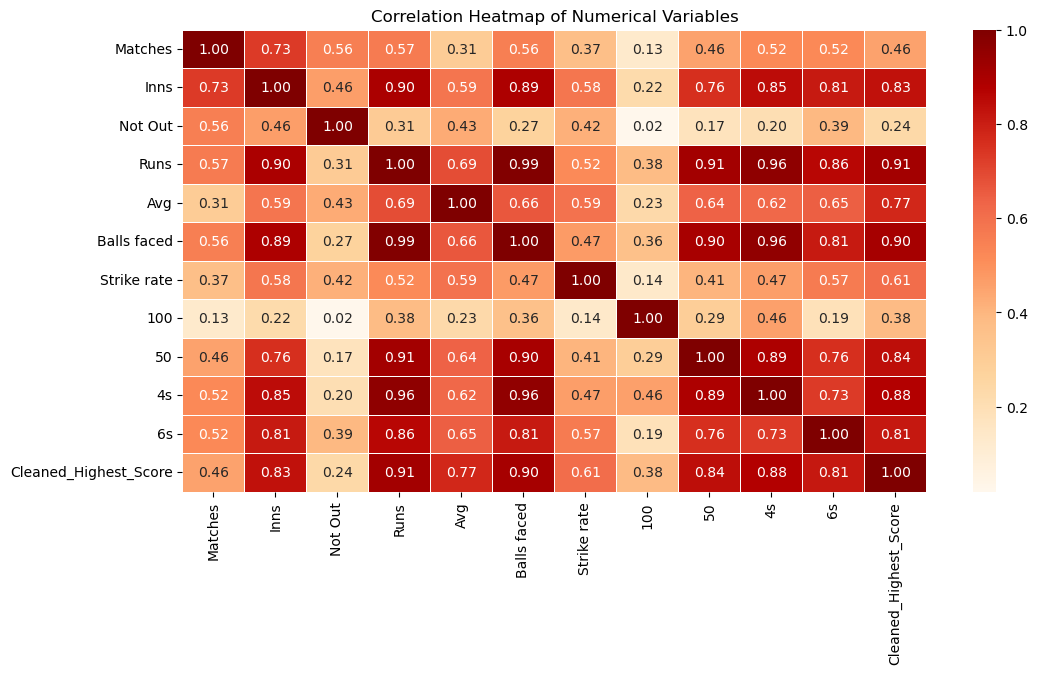

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap (numerical variables only)
plt.figure(figsize=(12, 6))
sns.heatmap(numeric_data.corr(), annot=True, cmap="OrRd", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

Q8. Check the list of players who has an average greater than 50 as well strike rate above 120. Print player name, average and strike rate.

In [23]:
Avg50_Strike120=df[(df['Avg']>50) & (df['Strike rate']>120)]
print("\nPlayers with Avg greater than 50 and Strike rate greater than 120 are:-\n")
Avg50_Strike120[['Player', 'Avg','Strike rate']]


Players with Avg greater than 50 and Strike rate greater than 120 are:-



,Player,Avg,Strike rate
0,KL Rahul,55.83,129.34
4,Ishan Kishan,57.33,145.76
31,Kieron Pollard,53.60,191.42
36,Wriddhiman Saha,71.33,139.86
37,Ruturaj Gaikwad,51.00,120.71
57,Deepak Hooda,101.00,142.25
60,Tom Curran,83.00,133.87


Q9. Please check the list of players who has an average greater than 40 and balls faced above 100. Print player name, average and balls faced.

In [25]:
Avg40_Balls100=df[(df['Avg']>40) & (df['Balls faced']>100)]
print("\nPlayers with Avg greater than 40 and Balls faced greater than 100 are:-\n")
Avg40_Balls100[['Player', 'Avg', 'Balls faced']]


Players with Avg greater than 40 and Balls faced greater than 100 are:-



,Player,Avg,Balls faced
0,KL Rahul,55.83,518
1,Shikhar Dhawan,44.14,427
4,Ishan Kishan,57.33,354
8,Virat Kohli,42.36,384
9,ABD Villiers,45.40,286
10,Faf Duplessis,40.81,319
14,Eoin Morgan,41.80,302
24,Kane Williamson,45.28,237
27,Chris Gayle,41.14,210
28,Ben Stokes,40.71,200


Q10. Players who scored atleast one century in this season. Create visualization.

In [27]:
Centuries_1=df[df['100']>=1]
Centuries_1[['Player','100']]
Player=Centuries_1['Player']
Centuries=Centuries_1['100']

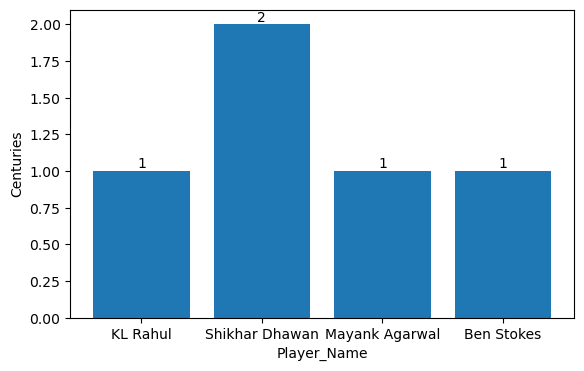

In [28]:
plt.figure(figsize=(6.5, 4))
bar_chart=plt.bar(Player,Centuries)
for bar in bar_chart:
    yval=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,yval,str(yval),ha='center', va='bottom')
plt.xlabel('Player_Name')
plt.ylabel('Centuries')
plt.show()

Q11. Players who scored atleast 4 half centuries in this season.

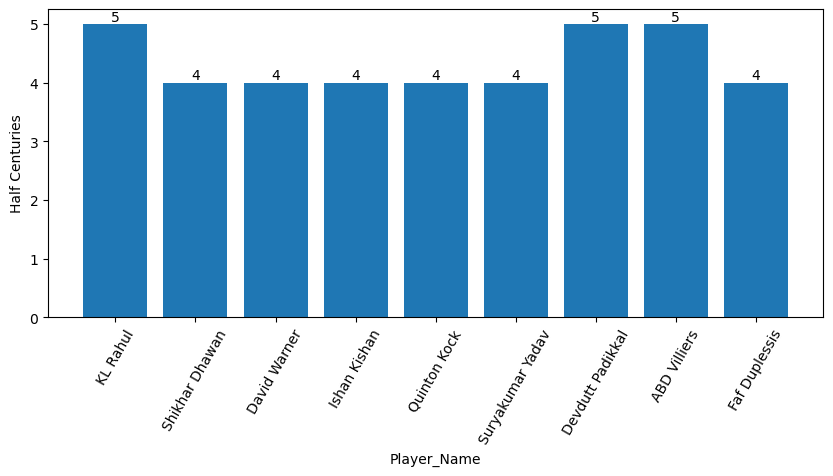

In [30]:
Half_Centuries_4=df[df['50']>=4]
Half_Centuries_4[['Player','50']]
Player_50=Half_Centuries_4['Player']
Half_Centuries=Half_Centuries_4['50']
plt.figure(figsize=(10, 4))
bar_chart=plt.bar(Player_50,Half_Centuries)
for bar in bar_chart:
    yval=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,yval,str(yval),ha='center', va='bottom')
plt.xlabel('Player_Name')
plt.ylabel('Half Centuries')
plt.xticks(rotation=60)
plt.show()

Q12. Check the list of players who hit more than 45 boundaries and more than 10 sixes in this season.

In [32]:
Player_4s_6s=df[(df['4s']>45) & (df['6s']>10)]

In [33]:
print('\nPlayers who more than 45 boundries and more than 10 sixes are:-\n')
Player_4s_6s[['Player','4s','6s']]


Players who more than 45 boundries and more than 10 sixes are:-



,Player,4s,6s
0,KL Rahul,58,23
1,Shikhar Dhawan,67,12
2,David Warner,52,14
5,Quinton Kock,46,22
6,Suryakumar Yadav,61,11


Q13. Plot a histogram of number of matches played in a season by players.

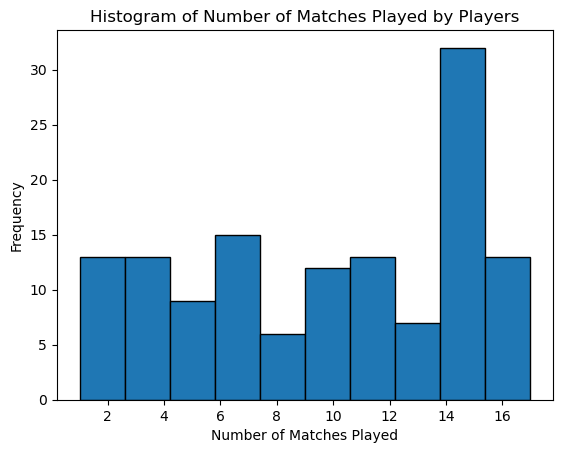

In [35]:
plt.hist(df['Matches'],histtype='bar',edgecolor='black')
plt.xlabel('Number of Matches Played')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Matches Played by Players')
plt.show()
#frequency (how many players have played a certain number of matches).

Q14. Plot the histogram of balls faced by players.

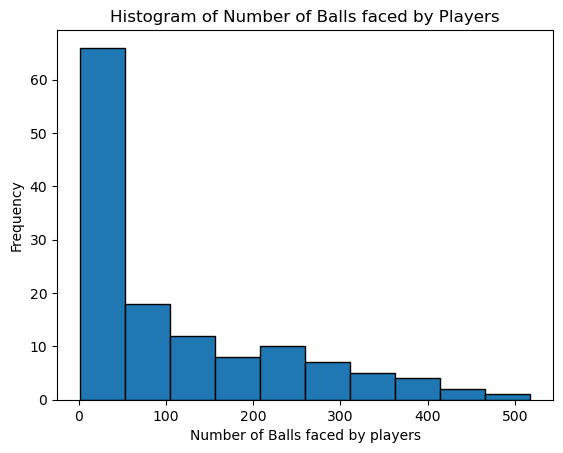

In [63]:
plt.hist(df['Balls faced'],histtype='bar',edgecolor='black')
plt.xlabel('Number of Balls faced by players')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Balls faced by Players')
plt.show()
#frequency (how many players have played a certain number of matches).

Q15. Top 10 players with most runs in a season.

In [91]:
Topten_Runs=df.sort_values(by='Runs',axis=0,ascending=False).head(10)
print("\nTop ten players with most runs are:-\n\n",Topten_Runs['Player'])


Top ten players with most runs are:-

 0            KL Rahul
1      Shikhar Dhawan
2        David Warner
3        Shreyas Iyer
4        Ishan Kishan
5        Quinton Kock
6    Suryakumar Yadav
7    Devdutt Padikkal
8         Virat Kohli
9        ABD Villiers
Name: Player, dtype: object


In [94]:
df.head()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Avg,Balls faced,Strike rate,100,50,4s,6s,First_name,Last_name,Cleaned_Highest_Score
0,1,KL Rahul,14,14,2,670,55.83,518,129.34,1,5,58,23,KL,Rahul,132
1,2,Shikhar Dhawan,17,17,3,618,44.14,427,144.73,2,4,67,12,Shikhar,Dhawan,106
2,3,David Warner,16,16,2,548,39.14,407,134.64,0,4,52,14,David,Warner,85
3,4,Shreyas Iyer,17,17,2,519,34.60,421,123.27,0,3,40,16,Shreyas,Iyer,88
4,5,Ishan Kishan,14,13,4,516,57.33,354,145.76,0,4,36,30,Ishan,Kishan,99


Q16. Print the players who played the match but didn't get the batting.

In [124]:
Player_nobat=df[df['Matches']>df['Inns']] #sorting players who played match, but did not bat
No_bat=Player_nobat['Matches']-Player_nobat['Inns'] #Number of matches where player did not bat
Player_nobat['No_bat']=No_bat
pd.set_option('display.max_rows', None)
Player_nobat[['Player','No_bat']]

C:\Users\rahul\AppData\Local\Temp\ipykernel_12244\1929226996.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Player_nobat['No_bat']=No_bat


,Player,No_bat
4,Ishan Kishan,1
6,Suryakumar Yadav,1
9,ABD Villiers,1
12,Manish Pandey,1
16,Ambati Rayudu,1
23,Jos Buttler,1
24,Kane Williamson,1
29,Hardik Pandya,1
31,Kieron Pollard,4
32,Rahul Tewatia,3


Q17. Create a new column to show the percentage of total runs scored in 4s and 6s. Then print the top 5 players with maximum percentage.

In [141]:
Runs_4s_6s=(4*df['4s']+6*df['6s'])
df['Percentage_runs']=round(((Runs_4s_6s/df['Runs'])*100),2) #rounding of percentage
df.head()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Avg,Balls faced,Strike rate,100,50,4s,6s,First_name,Last_name,Cleaned_Highest_Score,Percentage_runs
0,1,KL Rahul,14,14,2,670,55.83,518,129.34,1,5,58,23,KL,Rahul,132,55.22
1,2,Shikhar Dhawan,17,17,3,618,44.14,427,144.73,2,4,67,12,Shikhar,Dhawan,106,55.02
2,3,David Warner,16,16,2,548,39.14,407,134.64,0,4,52,14,David,Warner,85,53.28
3,4,Shreyas Iyer,17,17,2,519,34.60,421,123.27,0,3,40,16,Shreyas,Iyer,88,49.33
4,5,Ishan Kishan,14,13,4,516,57.33,354,145.76,0,4,36,30,Ishan,Kishan,99,62.79


Q18. Print the players with top 5 Not out percentages (Not Out percentage can be calculated as number of Not outs divided by Innings).

In [162]:
Notout_per=((df['Not Out']/df['Inns'])*100)
df['Notout_per']=Notout_per
df.sort_values(by='Notout_per',axis=0,ascending=False)[['Player','Notout_per']].head(5)

,Player,Notout_per
122,Shahbaz Ahmed,100.0
97,Mohammad Nabi,100.0
114,T Natarajan,100.0
116,Rahul Chahar,100.0
113,Dhawal Kulkarni,100.0


Q19. Create visualization of top 10 players with highest number of sixes.

In [173]:
Player_sixes=df.sort_values(by='6s',axis=0,ascending=False)
print("Top 10 players with maximum no of sixes are:\n-",Player_sixes[['Player','6s']].head(10))

Top 10 players with maximum no of sixes are:
-              Player  6s
4      Ishan Kishan  30
15     Sanju Samson  26
29    Hardik Pandya  25
17  Nicholas Pooran  25
14      Eoin Morgan  24
9      ABD Villiers  23
27      Chris Gayle  23
0          KL Rahul  23
31   Kieron Pollard  22
5      Quinton Kock  22


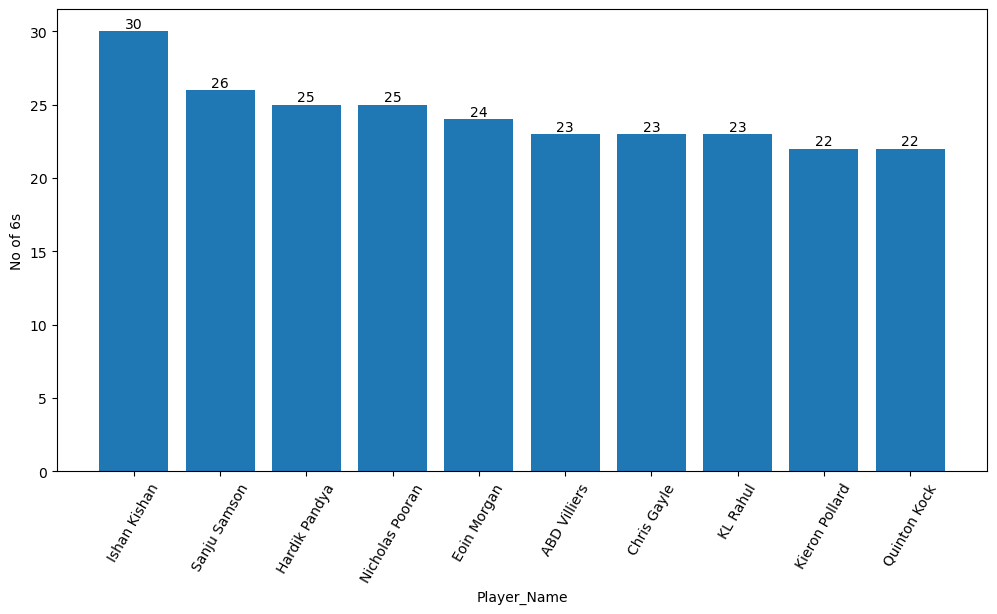

In [202]:
#Visualization
plt.figure(figsize=(12, 6))
Bar_chart=plt.bar(Player_sixes['Player'].head(10),Player_sixes['6s'].head(10))
for bar in Bar_chart:
    yval=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,yval,str(yval),ha='center', va='bottom')
plt.xlabel('Player_Name')
plt.ylabel("No of 6s")
plt.xticks(rotation=60)
plt.show()

Q20. Scatter plot of runs scored by a player v/s balls faced in a season. Then find the relationship between these 2 variables.

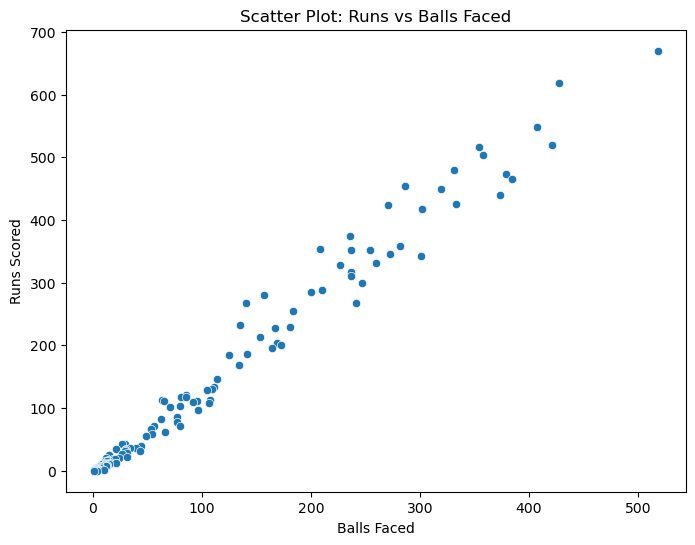

In [211]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Balls faced', y='Runs', data=df)
plt.title('Scatter Plot: Runs vs Balls Faced')
plt.xlabel('Balls Faced')
plt.ylabel('Runs Scored')
plt.show()

In [219]:
correlation = df['Runs'].corr(df['Balls faced'])
correlation

0.9899480233860839

As correlation is 0.9899 which shows a strong positive relation, which says that if number of balls faced increases number of runs scored will also increase. Correlation value also shows it as a approx linear relation.
This thing ios also visible from the scatter plot, dots are in roughly staright line.